# FlameIQ Refill Prediction — Model Evaluation

## Objective

This notebook performs detailed evaluation of the two selected FlameIQ proof-of-concept refill prediction models:

- **Cold-start model:** Lasso Regression
- **Personalised model:** Gradient Boosting Regression

The evaluation goes beyond overall model accuracy to examine:

- prediction-error behaviour,
- early versus late predictions,
- performance across user groups,
- model interpretability,
- feature importance,
- large prediction errors, and
- the effect of applying an operational refill safety buffer.

All results are based on labelled synthetic proof-of-concept data and are not production performance claims.

In [14]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [15]:
BASE_DIR = Path.cwd().resolve()

if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "data" / "processed"
REPORTS_DIR = BASE_DIR / "reports"
MODELS_DIR = BASE_DIR / "models"

refill_cycles = pd.read_csv(
    DATA_DIR / "refill_cycles_model.csv"
)

cold_predictions = pd.read_csv(
    REPORTS_DIR / "cold_start_test_predictions.csv"
)

personalised_predictions = pd.read_csv(
    REPORTS_DIR / "personalised_test_predictions.csv"
)

cold_model = joblib.load(
    MODELS_DIR / "cold_start_model.joblib"
)

personalised_model = joblib.load(
    MODELS_DIR / "personalised_model.joblib"
)

print("Refill cycles:", refill_cycles.shape)
print("Cold-start predictions:", cold_predictions.shape)
print("Personalised predictions:", personalised_predictions.shape)

Refill cycles: (8368, 16)
Cold-start predictions: (252, 5)
Personalised predictions: (1443, 5)


In [16]:
evaluation_features = [
    "user_id",
    "refill_cycle_id",
    "cylinder_size_kg",
    "refill_quantity_kg",
    "household_size",
    "meals_per_day",
    "cooking_days_per_week",
    "lpg_primary_fuel",
    "usage_change",
    "festive_period",
    "previous_cycle_days",
    "average_previous_cycle_days",
    "number_previous_cycles",
]

cold_eval = cold_predictions.merge(
    refill_cycles[evaluation_features],
    on=["user_id", "refill_cycle_id"],
    how="left"
)

personal_eval = personalised_predictions.merge(
    refill_cycles[evaluation_features],
    on=["user_id", "refill_cycle_id"],
    how="left"
)

for data in [cold_eval, personal_eval]:

    data["signed_error_days"] = (
        data["predicted_cycle_days"]
        - data["actual_cycle_days"]
    )

    data["absolute_error_days"] = (
        data["signed_error_days"].abs()
    )

print("Cold evaluation rows:", len(cold_eval))
print("Personalised evaluation rows:", len(personal_eval))

Cold evaluation rows: 252
Personalised evaluation rows: 1443


## 1. Detailed Error Analysis

Mean Absolute Error provides a useful overall measure, but it does not show whether errors are consistently early or late.

For FlameIQ, late predictions are particularly important because a prediction later than the actual refill cycle may allow a user to run out of LPG before receiving an appropriate refill recommendation.

The signed prediction error is therefore defined as:

`predicted cycle duration - actual cycle duration`

A positive value represents a late prediction, while a negative value represents an early prediction.

In [17]:
def error_summary(name, data):

    abs_error = data["absolute_error_days"]
    signed_error = data["signed_error_days"]

    summary = {
        "Pathway": name,
        "Observations": len(data),
        "MAE_days": abs_error.mean(),
        "Median_absolute_error": abs_error.median(),
        "90th_percentile_error": abs_error.quantile(0.90),
        "Maximum_absolute_error": abs_error.max(),
        "Within_2_days_pct": (abs_error <= 2).mean() * 100,
        "Within_5_days_pct": (abs_error <= 5).mean() * 100,
        "Late_prediction_pct": (signed_error > 0).mean() * 100,
        "Early_prediction_pct": (signed_error < 0).mean() * 100,
    }

    return pd.Series(summary)


error_summary_table = pd.DataFrame(
    [
        error_summary("Cold Start", cold_eval),
        error_summary("Personalised", personal_eval),
    ]
)

error_summary_table

,Pathway,Observations,MAE_days,Median_absolute_error,90th_percentile_error,Maximum_absolute_error,Within_2_days_pct,Within_5_days_pct,Late_prediction_pct,Early_prediction_pct
0,Cold Start,252,4.575357,3.58,9.820,21.59,31.746032,65.079365,54.761905,45.238095
1,Personalised,1443,3.320229,2.51,7.358,22.74,42.619543,77.477477,55.370755,44.490644


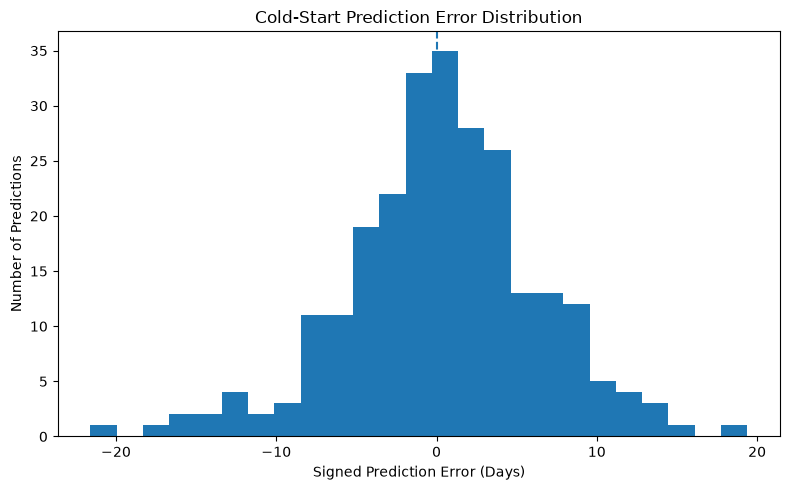

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(
    cold_eval["signed_error_days"],
    bins=25
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Cold-Start Prediction Error Distribution")
plt.xlabel("Signed Prediction Error (Days)")
plt.ylabel("Number of Predictions")

plt.tight_layout()
plt.show()

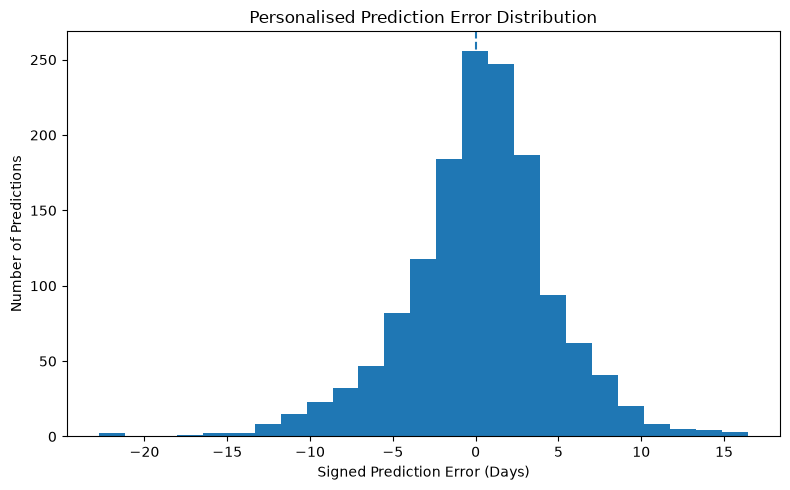

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(
    personal_eval["signed_error_days"],
    bins=25
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Personalised Prediction Error Distribution")
plt.xlabel("Signed Prediction Error (Days)")
plt.ylabel("Number of Predictions")

plt.tight_layout()
plt.show()

## 2. Performance Across Household Groups

Overall model performance can hide weaker performance within specific household groups.

The models are therefore evaluated separately by cylinder size and recent cooking-behaviour change.

In [20]:
def subgroup_performance(data, group_column):

    result = (
        data
        .groupby(group_column)
        .agg(
            observations=(
                "absolute_error_days",
                "size"
            ),
            MAE_days=(
                "absolute_error_days",
                "mean"
            ),
            median_error_days=(
                "absolute_error_days",
                "median"
            ),
            within_5_days_pct=(
                "absolute_error_days",
                lambda x: (x <= 5).mean() * 100
            ),
            late_prediction_pct=(
                "signed_error_days",
                lambda x: (x > 0).mean() * 100
            ),
        )
        .reset_index()
    )

    return result

In [21]:
print("COLD START — CYLINDER SIZE")

display(
    subgroup_performance(
        cold_eval,
        "cylinder_size_kg"
    )
)

print("\nPERSONALISED — CYLINDER SIZE")

display(
    subgroup_performance(
        personal_eval,
        "cylinder_size_kg"
    )
)

COLD START — CYLINDER SIZE


,cylinder_size_kg,observations,MAE_days,median_error_days,within_5_days_pct,late_prediction_pct
0,6.0,97,3.363196,2.81,74.226804,52.577320
1,12.5,155,5.333935,4.24,59.354839,56.129032



PERSONALISED — CYLINDER SIZE


,cylinder_size_kg,observations,MAE_days,median_error_days,within_5_days_pct,late_prediction_pct
0,6.0,547,2.300932,1.68,89.762340,53.747715
1,12.5,896,3.942500,3.19,69.977679,56.361607


In [22]:
print("COLD START — USAGE CHANGE")

display(
    subgroup_performance(
        cold_eval,
        "usage_change"
    )
)

print("\nPERSONALISED — USAGE CHANGE")

display(
    subgroup_performance(
        personal_eval,
        "usage_change"
    )
)

COLD START — USAGE CHANGE


,usage_change,observations,MAE_days,median_error_days,within_5_days_pct,late_prediction_pct
0,less,19,6.054211,4.370,52.631579,68.421053
1,more,23,3.996522,4.150,65.217391,47.826087
2,normal,210,4.504952,3.305,66.190476,54.285714



PERSONALISED — USAGE CHANGE


,usage_change,observations,MAE_days,median_error_days,within_5_days_pct,late_prediction_pct
0,less,130,4.684615,3.960,60.000000,47.692308
1,more,159,2.649560,1.900,83.647799,61.006289
2,normal,1154,3.258934,2.485,78.596187,55.459272


## 3. Cold-Start Model Interpretability

Lasso Regression is a linear model with regularisation.

Because numerical features were standardised during preprocessing, the fitted coefficients provide a useful indication of the direction and relative strength of each feature's contribution to the cold-start prediction.

Positive coefficients tend to increase predicted refill-cycle duration, while negative coefficients tend to shorten it.

In [34]:
cold_preprocessor = cold_model.named_steps[
    "preprocessor"
]

cold_estimator = cold_model.named_steps[
    "model"
]

cold_feature_names = (
    cold_preprocessor
    .get_feature_names_out()
)

cold_coefficients = pd.DataFrame(
    {
        "feature": cold_feature_names,
        "coefficient": cold_estimator.coef_
    }
)

cold_coefficients["feature"] = (
    cold_coefficients["feature"]
    .str.replace(
        "numeric__",
        "",
        regex=False
    )
    .str.replace(
        "categorical__",
        "",
        regex=False
    )
)

cold_coefficients["absolute_coefficient"] = (
    cold_coefficients["coefficient"].abs()
)

cold_coefficients = (
    cold_coefficients
    .sort_values(
        "absolute_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

cold_coefficients

,feature,coefficient,absolute_coefficient
0,refill_quantity_kg,9.619950,9.619950
1,usage_change_more,-6.765216,6.765216
2,usage_change_less,5.426322,5.426322
3,household_size,-4.108270,4.108270
4,lpg_primary_fuel,-4.095139,4.095139
5,meals_per_day,-2.969822,2.969822
6,cylinder_size_kg,1.081054,1.081054
7,festive_period,-0.563612,0.563612
8,cooking_days_per_week,-0.430255,0.430255
9,month_cos,0.270030,0.270030


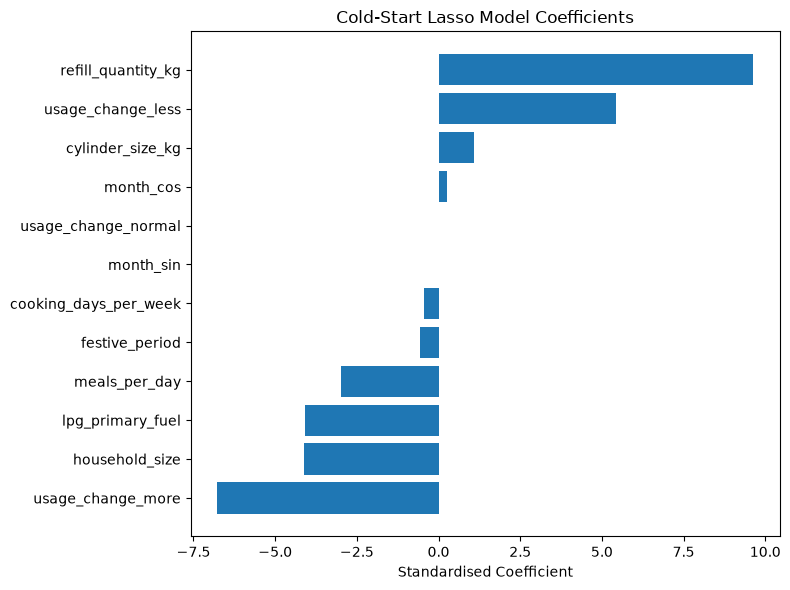

In [35]:
plot_data = (
    cold_coefficients
    .sort_values("coefficient")
)

plt.figure(figsize=(8, 6))

plt.barh(
    plot_data["feature"],
    plot_data["coefficient"]
)

plt.title("Cold-Start Lasso Model Coefficients")
plt.xlabel("Standardised Coefficient")

plt.tight_layout()
plt.show()

## 4. Personalised Model Feature Importance

The personalised model uses Gradient Boosting, which can capture nonlinear relationships and interactions between household characteristics and refill history.

Feature importance is examined to determine which inputs contribute most strongly to personalised predictions.

In [25]:
personal_preprocessor = (
    personalised_model
    .named_steps["preprocessor"]
)

personal_estimator = (
    personalised_model
    .named_steps["model"]
)

personal_feature_names = (
    personal_preprocessor
    .get_feature_names_out()
)

feature_importance = pd.DataFrame(
    {
        "feature": personal_feature_names,
        "importance":
            personal_estimator.feature_importances_
    }
)

feature_importance["feature"] = (
    feature_importance["feature"]
    .str.replace(
        "numeric__",
        "",
        regex=False
    )
    .str.replace(
        "categorical__",
        "",
        regex=False
    )
)

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance

,feature,importance
0,average_previous_cycle_days,0.697137
1,refill_quantity_kg,0.204138
2,usage_change_more,0.031181
3,usage_change_less,0.029285
4,lpg_primary_fuel,0.015203
5,household_size,0.009917
6,meals_per_day,0.005505
7,previous_cycle_days,0.003860
8,number_previous_cycles,0.000948
9,cylinder_size_kg,0.000728


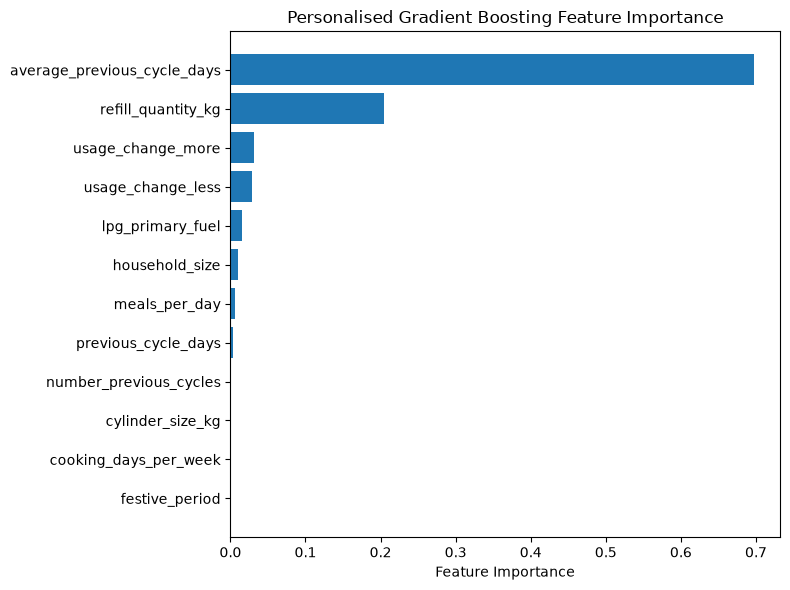

In [26]:
plot_importance = (
    feature_importance
    .head(12)
    .sort_values("importance")
)

plt.figure(figsize=(8, 6))

plt.barh(
    plot_importance["feature"],
    plot_importance["importance"]
)

plt.title(
    "Personalised Gradient Boosting Feature Importance"
)

plt.xlabel("Feature Importance")

plt.tight_layout()
plt.show()

## 5. Largest Prediction Errors

Examining the largest errors helps identify situations in which the selected models struggle.

This is especially important for a refill prediction product because extreme errors may represent users who would receive substantially premature or delayed refill recommendations.

In [27]:
cold_worst = (
    cold_eval
    .sort_values(
        "absolute_error_days",
        ascending=False
    )
    .head(10)
)

cold_worst[
    [
        "user_id",
        "cylinder_size_kg",
        "refill_quantity_kg",
        "household_size",
        "meals_per_day",
        "usage_change",
        "actual_cycle_days",
        "predicted_cycle_days",
        "signed_error_days",
        "absolute_error_days",
    ]
]

,user_id,cylinder_size_kg,refill_quantity_kg,household_size,meals_per_day,usage_change,actual_cycle_days,predicted_cycle_days,signed_error_days,absolute_error_days
36,USR_20216,12.5,10.20,6,1,less,61,39.41,-21.59,21.59
202,USR_21194,12.5,12.12,4,1,normal,26,45.38,19.38,19.38
147,USR_20812,12.5,12.25,2,1,normal,68,50.32,-17.68,17.68
235,USR_21396,12.5,12.44,4,2,normal,59,42.35,-16.65,16.65
28,USR_20171,12.5,12.03,5,2,normal,22,37.50,15.50,15.50
6,USR_20051,6.0,5.79,5,2,less,36,20.94,-15.06,15.06
160,USR_20925,12.5,11.64,4,1,normal,58,43.33,-14.67,14.67
162,USR_20930,12.5,11.99,4,2,normal,56,41.40,-14.60,14.60
150,USR_20842,6.0,3.59,3,1,normal,16,30.30,14.30,14.30
240,USR_21426,12.5,11.93,3,2,normal,28,42.24,14.24,14.24


In [28]:
personal_worst = (
    personal_eval
    .sort_values(
        "absolute_error_days",
        ascending=False
    )
    .head(10)
)

personal_worst[
    [
        "user_id",
        "cylinder_size_kg",
        "refill_quantity_kg",
        "household_size",
        "meals_per_day",
        "usage_change",
        "previous_cycle_days",
        "average_previous_cycle_days",
        "actual_cycle_days",
        "predicted_cycle_days",
        "signed_error_days",
        "absolute_error_days",
    ]
]

,user_id,cylinder_size_kg,refill_quantity_kg,household_size,meals_per_day,usage_change,previous_cycle_days,average_previous_cycle_days,actual_cycle_days,predicted_cycle_days,signed_error_days,absolute_error_days
725,USR_20730,12.5,11.72,4,2,normal,38.0,38.000000,66,43.26,-22.74,22.74
774,USR_20773,12.5,12.30,7,3,less,38.0,28.500000,58,36.80,-21.20,21.20
819,USR_20828,12.5,11.89,5,3,normal,23.0,23.000000,45,27.32,-17.68,17.68
284,USR_20302,12.5,12.21,4,2,normal,62.0,63.500000,52,68.42,16.42,16.42
555,USR_20560,12.5,11.97,5,2,less,23.0,30.500000,57,41.03,-15.97,15.97
900,USR_20930,12.5,11.71,4,2,normal,56.0,56.000000,38,53.82,15.82,15.82
1346,USR_21396,12.5,12.39,4,2,normal,59.0,59.000000,41,56.43,15.43,15.43
451,USR_20444,12.5,11.79,7,2,normal,19.0,26.666667,45,29.94,-15.06,15.06
818,USR_20812,12.5,12.16,2,1,normal,37.0,56.000000,71,56.19,-14.81,14.81
773,USR_20773,12.5,11.70,7,3,normal,19.0,19.000000,38,23.52,-14.48,14.48


## 6. Refill Recommendation Safety Buffer

The machine-learning model predicts the expected duration of a refill cycle.

However, FlameIQ should not necessarily advise the user to wait until the exact predicted depletion date before taking action.

A small operational safety buffer can shift the refill recommendation earlier without altering the underlying model prediction.

For example:

- Model-predicted cycle duration: 30 days
- Safety buffer: 3 days
- Recommended refill action: around day 27

This separates the statistical prediction from the product's risk-management decision.

In [29]:
def safety_buffer_analysis(data):

    results = []

    for buffer_days in range(0, 8):

        recommended_day = (
            data["predicted_cycle_days"]
            - buffer_days
        )

        # Positive means recommendation still occurs
        # after the actual refill/depletion point
        recommendation_error = (
            recommended_day
            - data["actual_cycle_days"]
        )

        lead_days = (
            data["actual_cycle_days"]
            - recommended_day
        )

        results.append(
            {
                "buffer_days": buffer_days,

                "late_recommendation_pct":
                    (
                        recommendation_error > 0
                    ).mean() * 100,

                "on_or_before_actual_pct":
                    (
                        recommendation_error <= 0
                    ).mean() * 100,

                "mean_lead_days":
                    lead_days.mean(),

                "median_lead_days":
                    lead_days.median(),

                "more_than_7_days_early_pct":
                    (
                        lead_days > 7
                    ).mean() * 100,
            }
        )

    return pd.DataFrame(results)

In [30]:
cold_buffer_results = (
    safety_buffer_analysis(
        cold_eval
    )
)

cold_buffer_results

,buffer_days,late_recommendation_pct,on_or_before_actual_pct,mean_lead_days,median_lead_days,more_than_7_days_early_pct
0,0,54.761905,45.238095,-0.369405,-0.54,9.523810
1,1,46.031746,53.968254,0.630595,0.46,12.698413
2,2,37.301587,62.698413,1.630595,1.46,15.079365
3,3,30.952381,69.047619,2.630595,2.46,19.444444
4,4,25.000000,75.000000,3.630595,3.46,26.190476
5,5,19.841270,80.158730,4.630595,4.46,30.952381
6,6,16.269841,83.730159,5.630595,5.46,39.285714
7,7,12.698413,87.301587,6.630595,6.46,45.238095


In [31]:
personal_buffer_results = (
    safety_buffer_analysis(
        personal_eval
    )
)

personal_buffer_results

,buffer_days,late_recommendation_pct,on_or_before_actual_pct,mean_lead_days,median_lead_days,more_than_7_days_early_pct
0,0,55.370755,44.629245,-0.221795,-0.48,5.890506
1,1,43.381843,56.618157,0.778205,0.52,8.246708
2,2,31.600832,68.399168,1.778205,1.52,10.533611
3,3,22.314622,77.685378,2.778205,2.52,14.691615
4,4,16.077616,83.922384,3.778205,3.52,19.265419
5,5,11.988912,88.011088,4.778205,4.52,25.779626
6,6,7.969508,92.030492,5.778205,5.52,34.442134
7,7,5.682606,94.317394,6.778205,6.52,44.490644


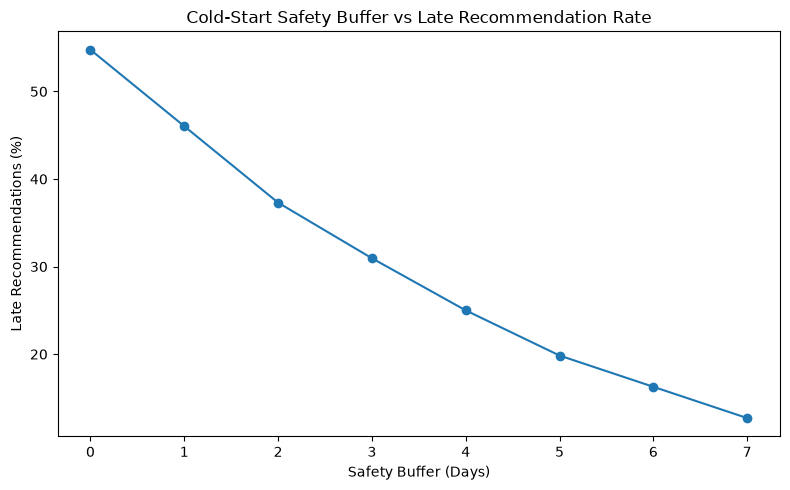

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    cold_buffer_results["buffer_days"],
    cold_buffer_results[
        "late_recommendation_pct"
    ],
    marker="o"
)

plt.title(
    "Cold-Start Safety Buffer vs Late Recommendation Rate"
)

plt.xlabel("Safety Buffer (Days)")
plt.ylabel("Late Recommendations (%)")

plt.tight_layout()
plt.show()

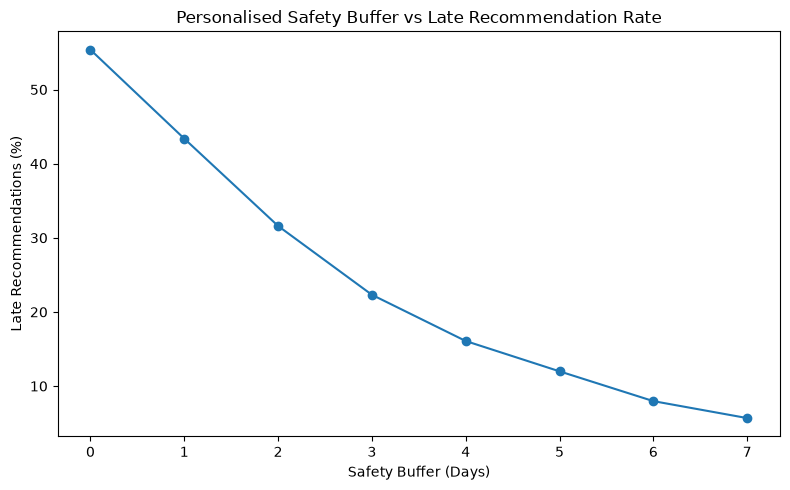

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    personal_buffer_results["buffer_days"],
    personal_buffer_results[
        "late_recommendation_pct"
    ],
    marker="o"
)

plt.title(
    "Personalised Safety Buffer vs Late Recommendation Rate"
)

plt.xlabel("Safety Buffer (Days)")
plt.ylabel("Late Recommendations (%)")

plt.tight_layout()
plt.show()

## Evaluation Status

The detailed evaluation examines model performance from both a statistical and product-risk perspective.

The analysis considers:

- average and extreme prediction errors,
- early versus late predictions,
- subgroup performance,
- cold-start model coefficients,
- personalised model feature importance, and
- the impact of applying an early refill recommendation buffer.

The model prediction itself should remain an unbiased estimate of expected refill-cycle duration. Any early-warning adjustment should be applied separately by the product recommendation layer.

The final safety-buffer choice and model-serving logic will be determined from the results of this evaluation before Backend integration.

In [36]:
personal_eval["history_stage"] = pd.cut(
    personal_eval["number_previous_cycles"],
    bins=[0, 1, 2, 4, float("inf")],
    labels=[
        "1 previous cycle",
        "2 previous cycles",
        "3-4 previous cycles",
        "5+ previous cycles"
    ],
    right=True
)

history_performance = (
    personal_eval
    .groupby(
        "history_stage",
        observed=True
    )
    .agg(
        observations=(
            "absolute_error_days",
            "size"
        ),
        MAE_days=(
            "absolute_error_days",
            "mean"
        ),
        median_error_days=(
            "absolute_error_days",
            "median"
        ),
        within_5_days_pct=(
            "absolute_error_days",
            lambda x: (x <= 5).mean() * 100
        ),
        late_prediction_pct=(
            "signed_error_days",
            lambda x: (x > 0).mean() * 100
        )
    )
    .reset_index()
)

history_performance

,history_stage,observations,MAE_days,median_error_days,within_5_days_pct,late_prediction_pct
0,1 previous cycle,252,4.028175,2.955,71.031746,53.571429
1,2 previous cycles,242,3.197645,2.370,80.578512,54.545455
2,3-4 previous cycles,425,3.150588,2.270,78.117647,55.294118
3,5+ previous cycles,524,3.173969,2.505,78.625954,56.679389


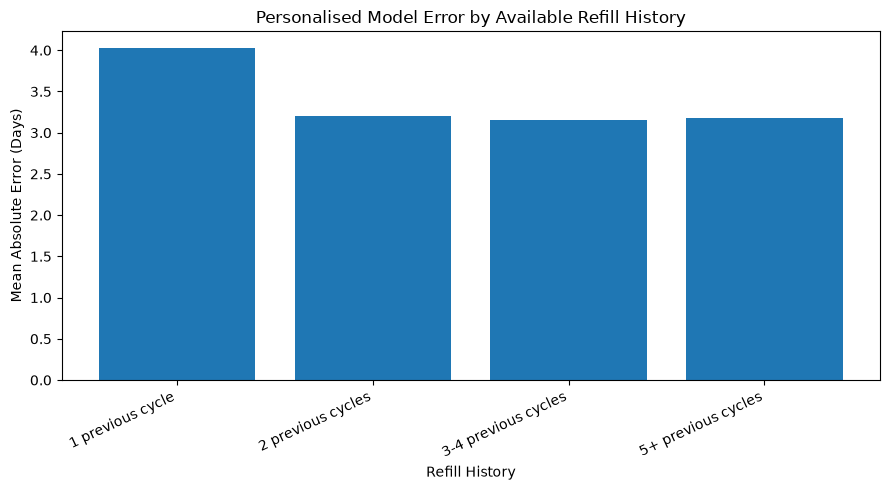

In [37]:
plt.figure(figsize=(9, 5))

plt.bar(
    history_performance["history_stage"].astype(str),
    history_performance["MAE_days"]
)

plt.title(
    "Personalised Model Error by Available Refill History"
)

plt.xlabel("Refill History")
plt.ylabel("Mean Absolute Error (Days)")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()